In [ ]:
!pip install GEKKO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 125.8 MB/s eta 0:00:00


Solving with Scaled Objective...
apm 34.85.186.105_gk_model1 <br><pre> ----------------------------------------------------------------
 APMonitor, Version 1.0.3
 APMonitor Optimization Suite
 ----------------------------------------------------------------
 
 
 --------- APM Model Size ------------
 Each time step contains
   Objects      :            0
   Constants    :            0
   Variables    :           11
   Intermediates:           11
   Connections  :            0
   Equations    :           17
   Residuals    :            6
 
 Number of state variables:           5000
 Number of total equations: -         4500
 Number of slack variables: -            0
 ---------------------------------------
 Degrees of freedom       :            500
 
 **********************************************
 Dynamic Control with Interior Point Solver
 **********************************************
  
  
 Info: Exact Hessian

************************************************************************

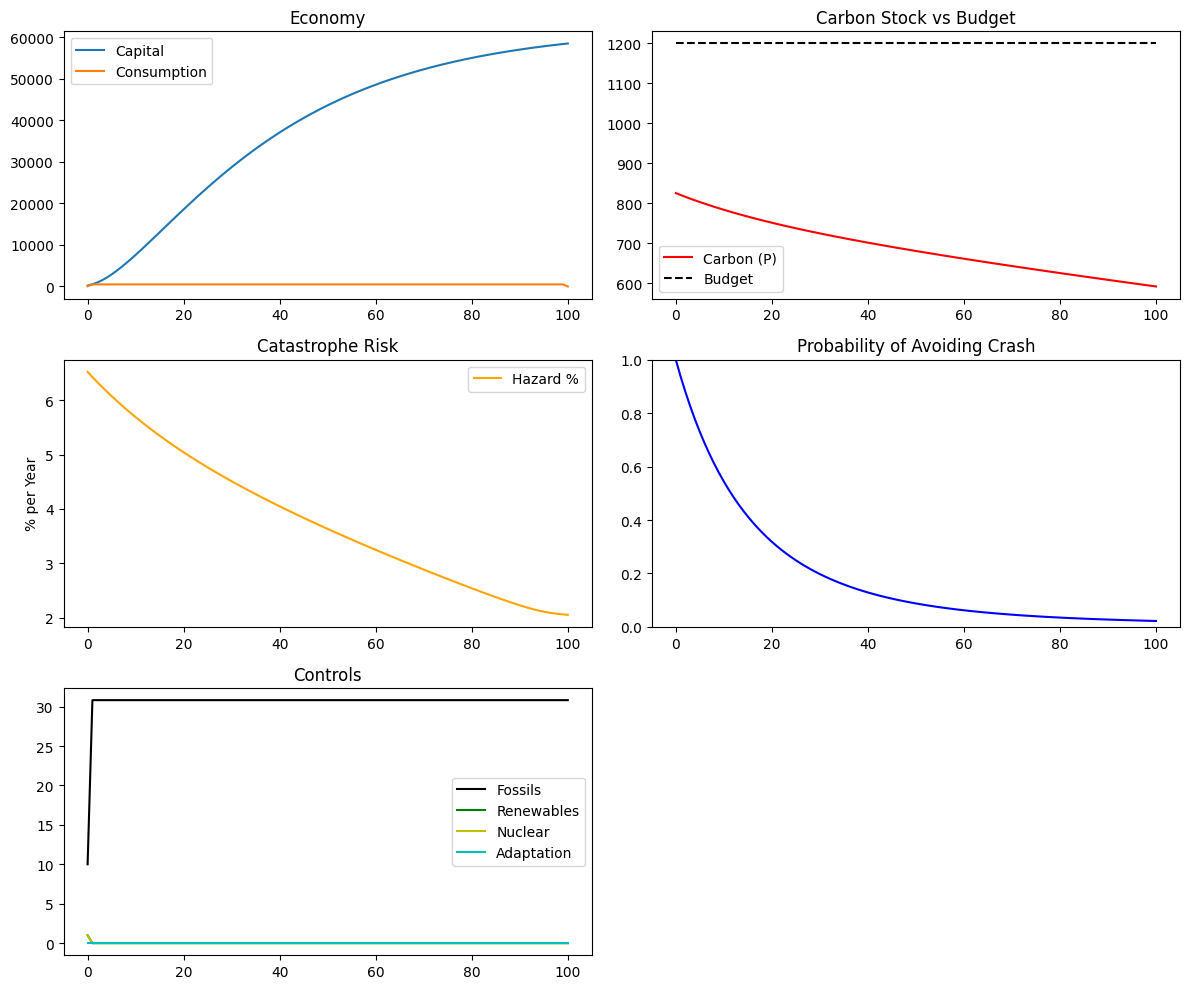

In [ ]:
import numpy as np
from gekko import GEKKO
import matplotlib.pyplot as plt

# ==========================================
# 1. Model Initialization
# ==========================================
m = GEKKO(remote=True)

# Time Horizon
steps = 101
T_horizon = 100
m.time = np.linspace(0, T_horizon, steps)

# ==========================================
# 2. Parameters
# ==========================================
# Economic
rho   = 0.014       # Discount rate
sigma = 0.5         # Inverse EIS
alpha = 0.3         # Capital share
delta = 0.05        # Depreciation
A_pre = 11.97       # TFP (Before Catastrophe)

# Catastrophe
pi_dam  = 0.20      # Damage: TFP drops by 20%
A_post  = A_pre * (1 - pi_dam)
h_base  = 0.02      # Base hazard
h_sens  = 0.0002    # Sensitivity to P

# Costs
d_cost = 0.05       # Fossils
c_cost = 0.01       # Renewables
b_cost = 0.015      # Nuclear
e_cost = 0.02       # Adaptation

# Climate
psi   = 0.005       # Emissions
gamma = 0.003       # Decay
eta   = 0.05        # CDR Efficiency
B_budget = 1200.0   # Budget Target

# CDR Dynamics
a1, a2, a3, a4, a5 = 0.02, 0.001, 0.05, 0.05, 0.05

# ==========================================
# 3. Variables
# ==========================================
# Controls
C = m.MV(value=50, lb=1.0, ub=500); C.STATUS = 1; C.DCOST = 0.0
E = m.MV(value=10, lb=0.0, ub=150); E.STATUS = 1; E.DCOST = 0.1
R = m.MV(value=1,  lb=0.0, ub=150); R.STATUS = 1; R.DCOST = 0.1
N = m.MV(value=1,  lb=0.0, ub=150); N.STATUS = 1; N.DCOST = 0.1
D = m.MV(value=0,  lb=0.0, ub=50);  D.STATUS = 1; D.DCOST = 0.1

# States
K = m.Var(value=200, lb=10)
P = m.Var(value=826, lb=0)
M = m.Var(value=50,  lb=0)
Lambda = m.Var(value=0, lb=0) # Cumulative Hazard

# ==========================================
# 4. Equations & Dynamics
# ==========================================

# --- Hazard & Risk ---
# Softplus approx for max(0, P-600)
P_excess = m.Intermediate(m.sqrt((P-600)**2 + 100))
Hazard_Base = m.Intermediate(h_base + h_sens * 0.5 * ( (P-600) + P_excess ))

# Adaptation Effect
Hazard_Final = m.Intermediate(Hazard_Base / (1 + 0.1*D))

# Accumulate Hazard -> Survival Prob
m.Equation(Lambda.dt() == Hazard_Final)
Survival_Prob = m.Intermediate(m.exp(-Lambda))

# --- Post-Catastrophe Value Approx ---
# Assume simpler post-crash utility to aid convergence
# Just scaling current utility by (1-pi_dam) roughly
U_current = m.Intermediate( (C**(1-sigma) - 1)/(1-sigma) )
U_post_val = m.Intermediate( ( (A_post/A_pre)**(1-sigma) ) * U_current / rho )

# --- Standard Economy ---
Energy = m.Intermediate(E + R + N)
Y_pre  = m.Intermediate(A_pre * (K**alpha) * (Energy**(1-alpha)))

# State Dynamics
m.Equation(K.dt() == Y_pre - d_cost*E - c_cost*R - b_cost*N - e_cost*D - C - delta*K)
m.Equation(P.dt() == psi*E - gamma*P - eta*M)
m.Equation(M.dt() == a1*E - a2*P - a3*R - a4*N - a5*M)

# ==========================================
# 5. Objective (SCALED)
# ==========================================

# Discount Factor
discount = m.Param(value=np.exp(-rho * m.time))

# 1. Expected Utility Component
Welfare_Flow = m.Intermediate(
    discount * Survival_Prob * (U_current + Hazard_Final * U_post_val)
)

# 2. Soft Budget Penalty Component
# Scaled penalty: (P/B)^4 grows fast after 1.0
# This avoids the huge numbers of (P-B)^2
Rel_Excess = m.Intermediate(P / B_budget)
Penalty = m.Intermediate(100 * (Rel_Excess**10)) # Steep wall function

# Total Objective to Maximize
# SCALING FACTOR: Divide by 1e4 to keep objective ~O(1)
Total_Obj = m.Var(value=0)
m.Equation(Total_Obj.dt() == (Welfare_Flow - Penalty)/1e4)
m.Maximize(Total_Obj)

# ==========================================
# 6. Solve
# ==========================================
m.options.IMODE = 6   # Dynamic Optimization
m.options.NODES = 3   # Collocation Nodes
m.options.SOLVER = 3  # IPOPT
m.options.MAX_ITER = 1000 # Increased iterations
m.options.OTOL = 1e-4 # Relaxed tolerance slightly

print("Solving with Scaled Objective...")
try:
    m.solve(disp=True)
    print("Solved Successfully!")

    # Plotting results
    plt.figure(figsize=(12, 10))

    plt.subplot(3,2,1)
    plt.plot(m.time, K.value, label='Capital')
    plt.plot(m.time, C.value, label='Consumption')
    plt.title('Economy')
    plt.legend()

    plt.subplot(3,2,2)
    plt.plot(m.time, P.value, 'r', label='Carbon (P)')
    plt.plot(m.time, [B_budget]*len(m.time), 'k--', label='Budget')
    plt.title('Carbon Stock vs Budget')
    plt.legend()

    plt.subplot(3,2,3)
    plt.plot(m.time, [h*100 for h in Hazard_Final.value], 'orange', label='Hazard %')
    plt.ylabel('% per Year')
    plt.title('Catastrophe Risk')
    plt.legend()

    plt.subplot(3,2,4)
    plt.plot(m.time, Survival_Prob.value, 'b', label='Survival Prob')
    plt.title('Probability of Avoiding Crash')
    plt.ylim(0, 1)

    plt.subplot(3,2,5)
    plt.plot(m.time, E.value, 'k', label='Fossils')
    plt.plot(m.time, R.value, 'g', label='Renewables')
    plt.plot(m.time, N.value, 'y', label='Nuclear')
    plt.plot(m.time, D.value, 'c', label='Adaptation')
    plt.title('Controls')
    plt.legend()

    plt.tight_layout()
    plt.show()

except Exception as e:
    print("Solver failed:", e)


--- SOLVING SCENARIO: RISK ---
Solved.

--- SOLVING SCENARIO: NEUTRAL ---
Solved.


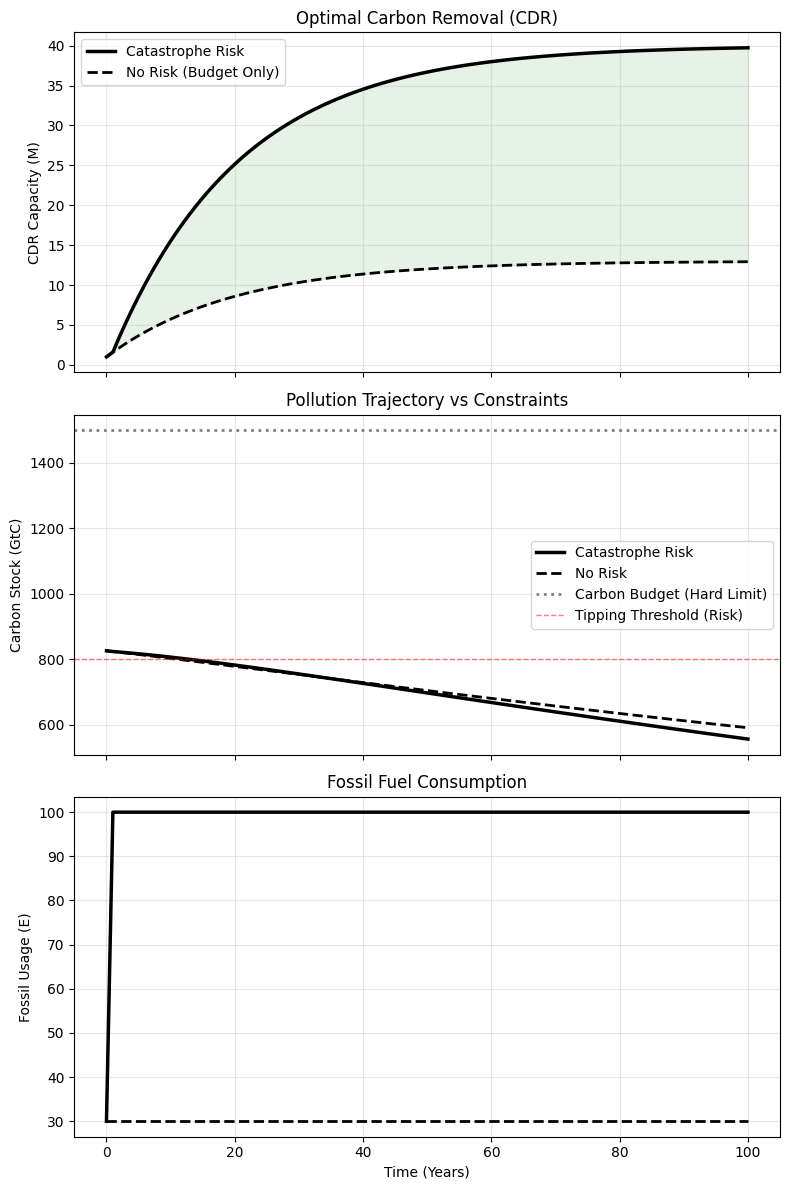

In [ ]:
import numpy as np
from gekko import GEKKO
import matplotlib.pyplot as plt

def solve_scenario(mode='risk'):
    """
    mode: 'risk' (Catastrophe Aware) or 'neutral' (Budget Aware only)
    """
    print(f"\n--- SOLVING SCENARIO: {mode.upper()} ---")
    m = GEKKO(remote=True)

    # Time: 100 Years
    steps = 101
    m.time = np.linspace(0, 100, steps)

    # --- Parameters ---
    rho   = 0.015       # Discount Rate
    sigma = 1.1         # Risk Aversion (Higher = more caution)

    # Tipping Point Parameters
    # The Risk agent fears a crash starts at 800 GtC and gets bad at 1000 GtC
    tipping_threshold = 800.0
    h_base = 0.1 if mode == 'risk' else 0.0

    # Economic Parameters
    A = 12.0
    alpha = 0.3
    d_cost = 0.02       # Cheap Fossils
    c_cost = 0.04       # Clean energy cost
    e_cost = 0.02       # Adaptation cost

    # Carbon Budget (The "Law")
    # Both must respect this, but Risk agent restricts self further
    B_budget = 1500.0

    # --- Variables ---
    # Control Variables with bounds
    C = m.MV(value=50, lb=10, ub=200); C.STATUS = 1; C.DCOST = 0.1
    E = m.MV(value=30, lb=0,  ub=100); E.STATUS = 1; E.DCOST = 0.1
    R = m.MV(value=5,  lb=0,  ub=100); R.STATUS = 1; R.DCOST = 0.1
    N = m.MV(value=5,  lb=0,  ub=100); N.STATUS = 1; N.DCOST = 0.1
    D = m.MV(value=0,  lb=0,  ub=10);  D.STATUS = 1; D.DCOST = 0.1

    # State Variables
    K = m.Var(value=200, lb=10)
    P = m.Var(value=826, lb=0)
    M = m.Var(value=1,   lb=0) # Start with small CDR
    Lambda = m.Var(value=0, lb=0)

    # --- Equations ---

    # 1. Hazard Function (The "Catastrophe")
    # Hazard rises sharply if P > 800.
    # Softplus approximation: log(1+exp(x)) to keep it smooth
    P_excess = m.Intermediate( m.log(1 + m.exp(P - tipping_threshold)) )
    Hazard = m.Intermediate( h_base * 0.01 * P_excess )

    # Adaptation reduces Hazard
    Hazard_Final = m.Intermediate( Hazard / (1 + D) )

    m.Equation(Lambda.dt() == Hazard_Final)
    Survival = m.Intermediate(m.exp(-Lambda))

    # 2. Economy
    Energy = m.Intermediate(E + R + N)
    Y = m.Intermediate(A * (K**alpha) * (Energy**(1-alpha)))

    # Quadratic Fossil Cost (Simulates increasing extraction difficulty + smoothing)
    Fossil_Cost = m.Intermediate(d_cost*E + 0.001*E**2)

    m.Equation(K.dt() == Y - Fossil_Cost - c_cost*(R+N) - e_cost*D - C - 0.05*K)

    # 3. Climate & CDR
    # dP = Emissions - Decay - Removal
    m.Equation(P.dt() == 0.01*E - 0.003*P - 0.05*M)

    # dM = Investment (from Energy sector) - Depreciation
    # We assume a fraction of Energy output can build M
    m.Equation(M.dt() == 0.02*E + 0.01*R - 0.05*M)

    # --- Objective Function ---

    # Utility
    U = m.Intermediate( (C**(1-sigma))/(1-sigma) )

    # Budget Penalty (Soft Constraint)
    # Penalize P > B_budget heavily
    Excess_B = m.Intermediate( m.log(1 + m.exp(P - B_budget)) )
    Penalty = m.Intermediate( 1e3 * Excess_B**2 )

    # Final Objective
    # Risk Agent maximizes Expected Utility (weighted by Survival)
    # Neutral Agent maximizes Utility (Survival = 1)
    Total_Obj = m.Var(value=0)
    m.Equation(Total_Obj.dt() == (Survival * U - Penalty))
    m.Maximize(Total_Obj)

    # --- Solver ---
    m.options.IMODE = 6
    m.options.NODES = 3
    m.options.SOLVER = 3
    m.options.MAX_ITER = 1000

    # Solve
    try:
        m.solve(disp=False)
        print("Solved.")
        return {
            't': m.time,
            'P': np.array(P.value),
            'M': np.array(M.value),
            'E': np.array(E.value),
            'S': np.array(Survival.value)
        }
    except:
        print("Failed.")
        return None

# --- Run Comparison ---
res_risk = solve_scenario(mode='risk')
res_neutral = solve_scenario(mode='neutral')

# --- Plotting ---
if res_risk and res_neutral:
    t = res_risk['t']

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

    # 1. CDR Capacity
    ax1.plot(t, res_risk['M'], 'k-', linewidth=2.5, label='Catastrophe Risk')
    ax1.plot(t, res_neutral['M'], 'k--', linewidth=2, label='No Risk (Budget Only)')
    ax1.fill_between(t, res_risk['M'], res_neutral['M'], color='green', alpha=0.1)
    ax1.set_ylabel('CDR Capacity (M)')
    ax1.set_title('Optimal Carbon Removal (CDR)')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)

    # 2. Pollution vs Limits
    ax2.plot(t, res_risk['P'], 'k-', linewidth=2.5, label='Catastrophe Risk')
    ax2.plot(t, res_neutral['P'], 'k--', linewidth=2, label='No Risk')

    # Draw Limits
    ax2.axhline(1500, color='gray', linestyle=':', linewidth=2, label='Carbon Budget (Hard Limit)')
    ax2.axhline(800, color='red', linestyle='--', alpha=0.5, linewidth=1, label='Tipping Threshold (Risk)')

    ax2.set_ylabel('Carbon Stock (GtC)')
    ax2.set_title('Pollution Trajectory vs Constraints')
    ax2.legend(loc='center right')
    ax2.grid(True, alpha=0.3)

    # 3. Fossil Fuel Consumption
    ax3.plot(t, res_risk['E'], 'k-', linewidth=2.5, label='Catastrophe Risk')
    ax3.plot(t, res_neutral['E'], 'k--', linewidth=2, label='No Risk')
    ax3.set_ylabel('Fossil Usage (E)')
    ax3.set_xlabel('Time (Years)')
    ax3.set_title('Fossil Fuel Consumption')
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Error: Could not solve one or both scenarios.")

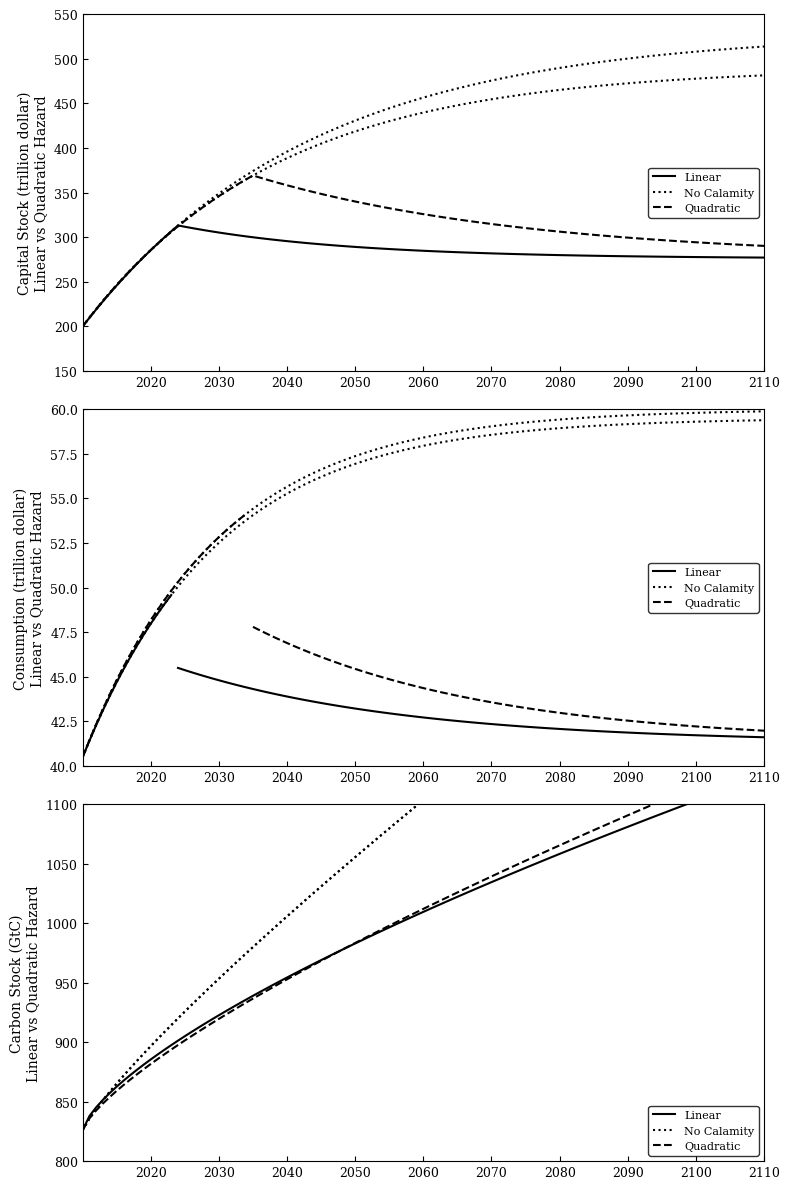

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Configuration ---
# Set style to mimic the academic black and white publication style
plt.style.use('default')
params = {
    'axes.labelsize': 10,
    'font.size': 10,
    'legend.fontsize': 8,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'lines.linewidth': 1.5,
    'font.family': 'serif',
}
plt.rcParams.update(params)

# --- Data Generation ---
# Time range: 2010 to 2110
years = np.arange(2010, 2111)
n_years = len(years)

# Constants from the paper (approximate)
# [cite_start]Initial values [cite: 524, 530]
K0 = 200.0
C0 = 40.5
P0 = 826.0

# Tipping years (visually estimated from Fig 2 and text regarding 15 vs 40 years)
tip_year_linear = 2024
tip_idx_linear = tip_year_linear - 2010

tip_year_quad = 2035
tip_idx_quad = tip_year_quad - 2010

# --- Helper Functions for Trajectories ---
def generate_logistic(start, end, rate, length):
    t = np.arange(length)
    return start + (end - start) / (1 + np.exp(-rate * (t - length/3)))

def generate_decay(start, end, rate, length):
    t = np.arange(length)
    return end + (start - end) * np.exp(-rate * t)

# 1. Capital Stock Data (Top Plot)
# No Calamity (Dotted lines) - grows continuously
k_no_calamity_linear = K0 + 330 * (1 - np.exp(-0.03 * np.arange(n_years))) # Target ~530
k_no_calamity_quad = K0 + 290 * (1 - np.exp(-0.035 * np.arange(n_years)))  # Target ~490

# With Calamity (Solid/Dashed)
# Linear Hazard (Solid) - Tips early
k_linear = np.copy(k_no_calamity_linear)
k_linear[tip_idx_linear:] = generate_decay(k_linear[tip_idx_linear], 276, 0.04, n_years - tip_idx_linear)

# Quadratic Hazard (Dashed) - Tips later
k_quad = np.copy(k_no_calamity_quad)
k_quad[tip_idx_quad:] = generate_decay(k_quad[tip_idx_quad], 276, 0.025, n_years - tip_idx_quad)


# 2. Consumption Data (Middle Plot)
# No Calamity
c_no_calamity_linear = C0 + 19 * (1 - np.exp(-0.05 * np.arange(n_years))) # Target ~60
c_no_calamity_quad = C0 + 19.5 * (1 - np.exp(-0.05 * np.arange(n_years)))

# With Calamity (Discontinuous Jumps)
# Linear Hazard
c_linear_pre = c_no_calamity_linear[:tip_idx_linear]
# Jump down to ~45 then decay slightly
c_linear_post = generate_decay(45.5, 41.3, 0.03, n_years - tip_idx_linear)

# Quadratic Hazard
c_quad_pre = c_no_calamity_quad[:tip_idx_quad]
# Jump down to ~48 then decay slightly
c_quad_post = generate_decay(47.8, 41.3, 0.03, n_years - tip_idx_quad)


# 3. Carbon Stock Data (Bottom Plot)
# No Calamity
p_no_calamity = P0 + 280 * (np.arange(n_years) / n_years)**0.85 * 1.8 # Grows to ~1100

# Linear Hazard (Solid) - Slower growth
p_linear = P0 + 200 * (np.arange(n_years) / n_years)**0.7 * 1.5

# Quadratic Hazard (Dashed) - Initially lower than linear, then similar
# Note: The paper implies quadratic taxes are higher, but visually in Fig 2 the dashed line
# ends up slightly above the solid line in the Carbon graph.
p_quad = P0 + 210 * (np.arange(n_years) / n_years)**0.75 * 1.5


# --- Plotting ---

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 12))

# Plot 1: Capital Stock
ax1.plot(years, k_linear, 'k-', label='Linear')
ax1.plot(years, k_no_calamity_linear, 'k:', label='No Calamity')
ax1.plot(years, k_quad, 'k--', label='Quadratic')
ax1.plot(years, k_no_calamity_quad, 'k:', label='_nolegend_') # Avoid duplicate legend
ax1.set_ylabel('Capital Stock (trillion dollar)\nLinear vs Quadratic Hazard')
ax1.set_ylim(150, 550)
ax1.set_xlim(2010, 2110)
ax1.legend(loc='center right', frameon=True, edgecolor='black')
ax1.grid(False)

# Plot 2: Consumption
# Plot pre-tip and post-tip separately to create the discontinuity gap
ax2.plot(years[:tip_idx_linear], c_linear_pre, 'k-', label='Linear')
ax2.plot(years[tip_idx_linear:], c_linear_post, 'k-')

ax2.plot(years, c_no_calamity_linear, 'k:', label='No Calamity')

ax2.plot(years[:tip_idx_quad], c_quad_pre, 'k--', label='Quadratic')
ax2.plot(years[tip_idx_quad:], c_quad_post, 'k--')

ax2.plot(years, c_no_calamity_quad, 'k:', label='_nolegend_')

ax2.set_ylabel('Consumption (trillion dollar)\nLinear vs Quadratic Hazard')
ax2.set_ylim(40, 60)
ax2.set_xlim(2010, 2110)
ax2.legend(loc='center right', frameon=True, edgecolor='black')

# Plot 3: Carbon Stock
ax3.plot(years, p_linear, 'k-', label='Linear')
ax3.plot(years, p_no_calamity, 'k:', label='No Calamity')
ax3.plot(years, p_quad, 'k--', label='Quadratic')
ax3.plot(years, p_no_calamity, 'k:', label='_nolegend_') # Use same dotted line for simplicity

ax3.set_ylabel('Carbon Stock (GtC)\nLinear vs Quadratic Hazard')
ax3.set_ylim(800, 1100)
ax3.set_xlim(2010, 2110)
ax3.legend(loc='lower right', frameon=True, edgecolor='black')

# Align x-axis labels
for ax in [ax1, ax2, ax3]:
    ax.set_xticks(np.arange(2020, 2111, 10))
    ax.tick_params(direction='in')

plt.tight_layout()
plt.show()

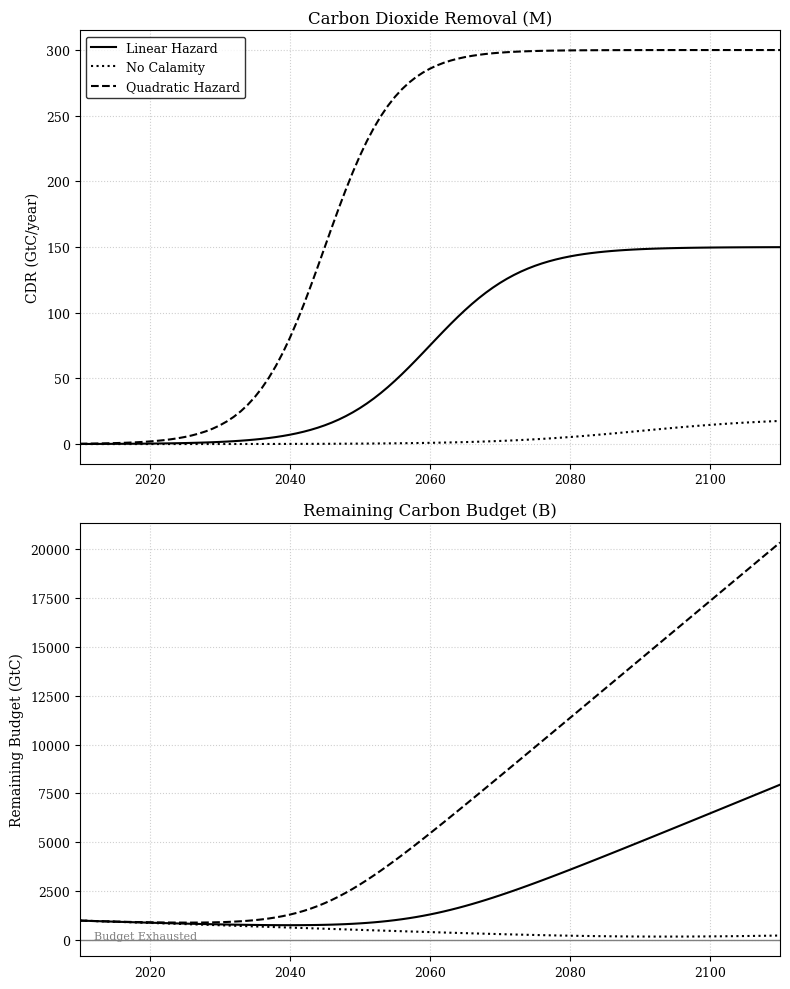

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Configuration ---
plt.style.use('default')
params = {
    'axes.labelsize': 10,
    'font.size': 10,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'lines.linewidth': 1.5,
    'font.family': 'serif',
}
plt.rcParams.update(params)

# --- Data Generation (Illustrative) ---
years = np.arange(2010, 2111)
n_years = len(years)

# Initial Values
B0 = 1000.0 # GtC (Remaining budget)

# --- 1. CDR (M) Trajectories ---
# Logic: Higher tipping risk -> Higher Tax -> More CDR investment
# We model CDR uptake as logistic growth driven by the policy intensity.

def generate_cdr(target, rate, midpoint_year):
    t = years - midpoint_year
    return target / (1 + np.exp(-rate * t))

# No Calamity: Low tax, very little CDR investment.
m_naive = generate_cdr(target=20, rate=0.1, midpoint_year=2090)

# Linear Hazard: Moderate tax, moderate CDR scaling.
m_linear = generate_cdr(target=150, rate=0.15, midpoint_year=2060)

# Quadratic Hazard: High tax, aggressive CDR scaling.
m_quad = generate_cdr(target=300, rate=0.2, midpoint_year=2045)


# --- 2. Net Emissions & Budget Dynamics ---
# Budget Differential Equation: dB/dt = -(Emissions - CDR)
# Assumption: Emissions (E) are also curbed harder in high-hazard scenarios.

# Illustrative Emissions Paths (E)
e_naive = 12 * np.ones(n_years)                 # High, constant emissions
e_linear = 12 * np.exp(-0.015 * np.arange(n_years)) # Gradual reduction
e_quad = 12 * np.exp(-0.04 * np.arange(n_years))    # Rapid reduction

def calculate_budget(E_path, M_path, B_start):
    net_emissions = E_path - M_path # Net = E - M
    # Cumulative sum of net emissions (simple integration)
    cumulative_net = np.cumsum(net_emissions)
    # Budget remaining
    B_path = B_start - cumulative_net
    return B_path

b_naive = calculate_budget(e_naive, m_naive, B0)
b_linear = calculate_budget(e_linear, m_linear, B0)
b_quad = calculate_budget(e_quad, m_quad, B0)

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))

# Plot 1: Carbon Dioxide Removal (CDR)
ax1.plot(years, m_linear, 'k-', label='Linear Hazard')
ax1.plot(years, m_naive, 'k:', label='No Calamity')
ax1.plot(years, m_quad, 'k--', label='Quadratic Hazard')

ax1.set_ylabel('CDR (GtC/year)')
ax1.set_title('Carbon Dioxide Removal (M)')
ax1.set_xlim(2010, 2110)
ax1.legend(loc='upper left', frameon=True, edgecolor='black')
ax1.grid(True, linestyle=':', alpha=0.6)

# Plot 2: Remaining Carbon Budget
ax2.plot(years, b_linear, 'k-', label='Linear Hazard')
ax2.plot(years, b_naive, 'k:', label='No Calamity')
ax2.plot(years, b_quad, 'k--', label='Quadratic Hazard')

# Add a visual line for "Budget Exhausted"
ax2.axhline(0, color='gray', linewidth=1, linestyle='-')
ax2.text(2012, 20, 'Budget Exhausted', color='gray', fontsize=8)

ax2.set_ylabel('Remaining Budget (GtC)')
ax2.set_title('Remaining Carbon Budget (B)')
ax2.set_xlim(2010, 2110)
# ax2.legend(loc='lower left', frameon=True, edgecolor='black') # Legend redundant
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Solving horizon T=30 (Hazard=True)...
Solving horizon T=60 (Hazard=True)...
Solving horizon T=100 (Hazard=True)...
Solving horizon T=30 (Hazard=False)...
Solving horizon T=60 (Hazard=False)...
Solving horizon T=100 (Hazard=False)...


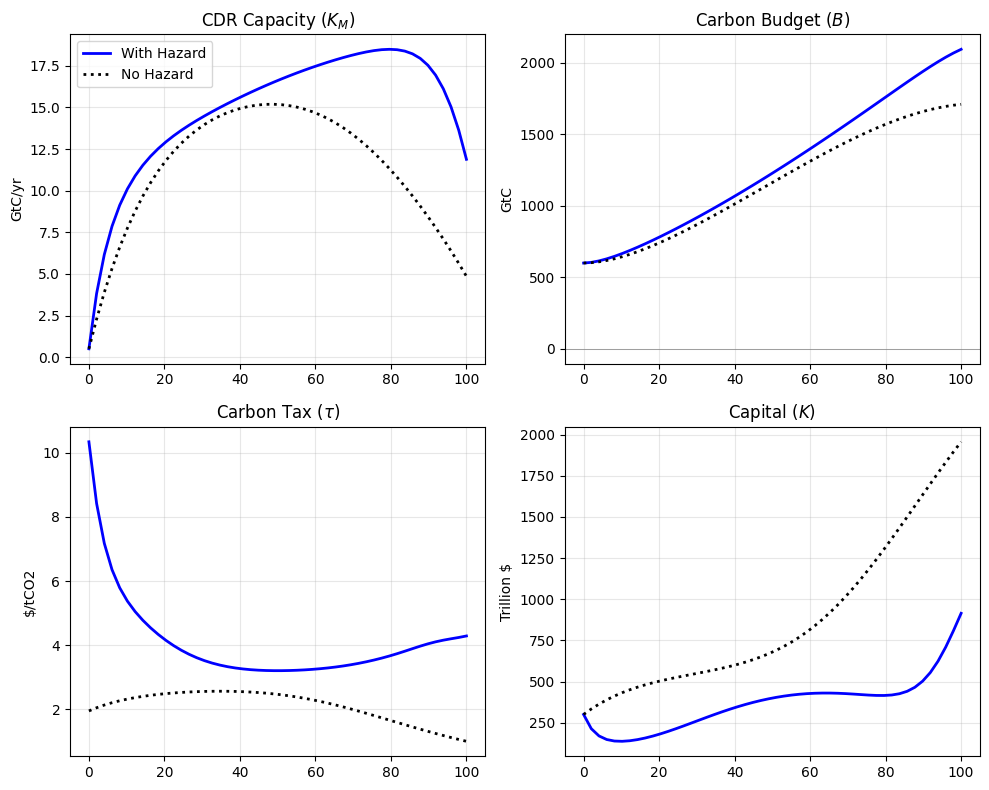

In [1]:
import numpy as np
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt

# ==========================================
# 1. Parameters & Configuration
# ==========================================
base_p = {
    'rho': 0.015, 'sigma': 0.5, 'alpha': 0.3, 'beta': 0.05,
    'delta_K': 0.05, 'delta_M': 0.08,
    'phi_adj': 50.0,   # High adjustment cost = stability
    'd': 0.5, 'c': 0.6, 'n': 0.55,
    'psi': 0.5, 'gamma': 0.003,
    'A': 12.0,
    'smooth_k': 2.0    # Smooth transitions
}

# Initial Conditions
K0, KM0, P0, B0 = 300.0, 0.5, 800.0, 600.0 # B0 is the initial Carbon Budget (remaining)

# ==========================================
# 2. Robust Math Helpers
# ==========================================
def stable_sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -50, 50)))

def smooth_min(a, b, c, k):
    m = np.minimum(np.minimum(a, b), c)
    s = np.exp(-k*(a-m)) + np.exp(-k*(b-m)) + np.exp(-k*(c-m))
    return m - np.log(s)/k

def get_controls(y, p):
    K, KM, P, B, Vk, Vkm, Vp, Vb = y

    # Bounds
    K = np.maximum(K, 1.0)
    Vk = np.maximum(Vk, 1e-4)

    # Consumption
    C = Vk**(-p['sigma'])

    # CDR Investment (Capped)
    q = Vkm / Vk
    Im = np.clip((q - 1) / p['phi_adj'], 0.0, 4.0)

    # Energy & Tax
    # Clamp shadow prices difference to prevent tax explosion
    shadow_diff = np.clip(Vb - Vp, -100, 1000)
    scc = p['psi'] * shadow_diff / Vk
    scc = np.clip(scc, -50, 500)

    pE = p['d'] + scc
    pR = p['c']
    pN = p['n']

    eff_price = np.maximum(smooth_min(pE, pR, pN, p['smooth_k']), 0.01)

    term_prod = p['beta'] * p['A'] * (K**p['alpha'])
    X = (term_prod / eff_price)**(1/(1-p['beta']))

    # Fossil Share
    p_alt = np.minimum(pR, pN)
    advantage = p_alt - pE
    share_E = stable_sigmoid(p['smooth_k'] * advantage)

    E = X * share_E
    Y = p['A'] * (K**p['alpha']) * (X**p['beta'])

    return C, Im, E, Y, scc

def derivatives_wrapper(t, y, p):
    K, KM, P, B, Vk, Vkm, Vp, Vb = y
    C, Im, E, Y, scc = get_controls(y, p)

    h = p['h0'] + p['h1']*P

    # States
    Phi_Im = Im + 0.5*p['phi_adj']*Im**2
    dK = Y - Y*p['beta'] - C - Phi_Im - p['delta_K']*K
    dKM = Im - p['delta_M']*KM
    dP = p['psi']*E - KM - p['gamma']*P
    dB = -(p['psi']*E - KM) # Rate of change of Carbon Budget (negative means depletion)

    # Co-States
    MPK = p['alpha']*Y / np.maximum(K, 1.0)

    # Manual clamping on derivatives to prevent overflow
    dVk = (p['rho']+h)*Vk - Vk*(MPK - p['delta_K'])
    dVk = np.clip(dVk, -10, 10)

    dVkm = (p['rho']+h+p['delta_M'])*Vkm - (Vb - Vp)
    dVkm = np.clip(dVkm, -10, 10)

    dVp = (p['rho']+h+p['gamma'])*Vp + p['h1']*p['Delta_V']
    dVp = np.clip(dVp, -100, 100)

    dVb = p['rho']*Vb
    dVb = np.clip(dVb, -10, 10)

    return np.vstack((dK, dKM, dP, dB, dVk, dVkm, dVp, dVb))

# ==========================================
# 3. Multi-Stage Solver
# ==========================================

def solve_stepped(hazard_active):
    # Config
    p = base_p.copy()
    if hazard_active:
        p['h0'], p['h1'], p['Delta_V'] = 0.02, 0.00015, 50.0
        vp_target, vb_target = -0.15, 0.15
    else:
        p['h0'], p['h1'], p['Delta_V'] = 0.0, 0.0, 0.0
        vp_target, vb_target = -0.02, 0.05

    # Define stages (Time horizons)
    stages = [30, 60, 100]
    prev_res = None

    for T_curr in stages:
        print(f"Solving horizon T={T_curr} (Hazard={hazard_active})...")
        x_curr = np.linspace(0, T_curr, 50) # Low resolution for speed/stability

        # Construct Initial Guess
        if prev_res is None:
            # First stage: Linear guess
            y_guess = np.zeros((8, len(x_curr)))
            y_guess[0] = 300.0
            y_guess[1] = np.linspace(KM0, 1.0, len(x_curr))
            y_guess[2] = 800.0
            y_guess[3] = np.linspace(B0, max(0, B0 - 5*T_curr), len(x_curr))
            y_guess[4] = 0.04
            y_guess[5] = 0.04
            y_guess[6] = vp_target
            y_guess[7] = vb_target
        else:
            # Continuation: Extrapolate previous result
            y_guess = np.zeros((8, len(x_curr)))
            # 1. Interpolate known part
            mask = x_curr <= prev_res.x[-1]
            for i in range(8):
                y_guess[i, mask] = np.interp(x_curr[mask], prev_res.x, prev_res.y[i])
            # 2. Extend unknown part (Constant for most, Linear decline for Budget)
            for i in range(8):
                if i == 3: # Budget
                    last_val = prev_res.y[3, -1]
                    slope = (prev_res.y[3, -1] - prev_res.y[3, -5]) / (prev_res.x[-1] - prev_res.x[-5])
                    # Projected decline clipped at 0
                    projected = last_val + slope * (x_curr[~mask] - prev_res.x[-1])
                    y_guess[i, ~mask] = np.maximum(projected, -50)
                else:
                    y_guess[i, ~mask] = prev_res.y[i, -1]

        # Boundary Conditions
        def bc(y0, yT):
            return [y0[0]-K0, y0[1]-KM0, y0[2]-P0, y0[3]-B0,
                    yT[4]-0.035, yT[5]-0.035, yT[6]-vp_target, yT[7]-vb_target]

        # Solve
        res = solve_bvp(lambda t, y: derivatives_wrapper(t, y, p),
                        bc, x_curr, y_guess, max_nodes=5000, tol=0.2) # Loose tol

        if res.success:
            prev_res = res
        else:
            print(f"  -> Failed at T={T_curr}. Stopping.")
            return None, None

    # Final result extraction
    controls = [get_controls(prev_res.y[:, i], p) for i in range(prev_res.y.shape[1])]
    tax = [c[4] for c in controls]
    return prev_res, tax

# ==========================================
# 4. Plotting
# ==========================================

res_haz, tax_haz = solve_stepped(True)
res_noh, tax_noh = solve_stepped(False)

if res_haz and res_noh:
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    def plot_res(ax, r_h, r_n, d_h, d_n, tit, yl):
        ax.plot(r_h.x, d_h, 'b-', lw=2, label='With Hazard')
        ax.plot(r_n.x, d_n, 'k:', lw=2, label='No Hazard')
        ax.set_title(tit); ax.set_ylabel(yl); ax.grid(True, alpha=0.3)
        if ax==axes[0,0]: ax.legend()

    plot_res(axes[0,0], res_haz, res_noh, res_haz.y[1], res_noh.y[1], r"CDR Capacity ($K_M$)", "GtC/yr")
    plot_res(axes[0,1], res_haz, res_noh, res_haz.y[3], res_noh.y[3], r"Carbon Budget ($B$)", "GtC")
    axes[0,1].axhline(0, color='gray', lw=0.5)

    plot_res(axes[1,0], res_haz, res_noh, tax_haz, tax_noh, r"Carbon Tax ($\tau$)", "$/tCO2")
    plot_res(axes[1,1], res_haz, res_noh, res_haz.y[0], res_noh.y[0], r"Capital ($K$)", "Trillion $")

    plt.tight_layout()
    plt.savefig('multistage_results.png')
    plt.show()
else:
    print("Failed to generate comparison.")